In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay)

In [26]:
# Cleaned Data
df = pd.read_csv('../data/heart_disease_clean.csv')

 ## 1. Problem Definition
- **Task type:** Supervised learning — **binary classification**
- **Target:** `Result` → `positive` (heart attack) vs. `negative` (no heart attack)
- **Features:** Age, Gender, Heart rate, Systolic blood pressure, Diastolic blood pressure, Blood sugar, CK-MB, Troponin
- **Class balance:** ~61% positive / 39% negative → moderately imbalanced, so accuracy alone will be
  misleading. We'll report precision, recall, and F1 alongside it.

In [27]:
# Preprocessing (Encoding)
df['Result'] = df['Result'].map({'negative': 0, 'positive': 1})
df['Result'].value_counts()


Result
1    808
0    508
Name: count, dtype: int64

In [28]:
# X \ Y split
X= df.drop('Result', axis=1)
y=df['Result']

In [29]:
# Train \ Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [30]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
#Creating and fitting the baseline model
baseline_model =LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## BaseLine Model (Logistic Regression)

In [ ]:
pred_baseline = baseline_model.predict(X_test_scaled)
proba_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Baseline (Logistic Regression) — Test Set Performance")
print("Accuracy:", accuracy_score(y_test,pred_baseline))
print("Precision:", precision_score(y_test,pred_baseline))
print("Recall:",recall_score(y_test, pred_baseline))
print("F1 Score:",f1_score(y_test, pred_baseline))
print("ROC-AUC:", roc_auc_score(y_test, proba_baseline))

Baseline (Logistic Regression) — Test Set Performance
Accuracy: 0.7916666666666666
Precision: 0.8282208588957055
Recall: 0.8333333333333334
F1 Score: 0.8307692307692308
ROC-AUC: 0.8892519970951344


## Second Model Random Forest: 
A second, more flexible model to compare against the baseline.

In [48]:

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

pred_rf = rf_model.predict(X_test_scaled)
proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest — Test Set Performance")
print("Accuracy:", accuracy_score(y_test,pred_rf))
print("Precision:", precision_score(y_test,pred_rf))
print("Recall:",recall_score(y_test, pred_rf))
print("F1 Score:",f1_score(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))

Random Forest — Test Set Performance
Accuracy: 0.9924242424242424
Precision: 0.9878048780487805
Recall: 1.0
F1 Score: 0.9938650306748467
ROC-AUC: 0.9977003146937787


In [37]:
# Check for Overfitting 
train_pred =rf_model.predict(X_train_scaled)

print("Random Forest — Test Set Performance")
print("Accuracy:", accuracy_score(y_train,train_pred))
print("Precision:", precision_score(y_train,train_pred))
print("Recall:",recall_score(y_train,train_pred))
print("F1 Score:",f1_score(y_train,train_pred))
print("ROC-AUC:", roc_auc_score(y_train,train_pred))

Random Forest — Test Set Performance
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [49]:
# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results_baseline = cross_validate(baseline_model, X_train_scaled, y_train, cv=cv, scoring=scoring)
cv_results_rf = cross_validate(rf_model, X_train_scaled, y_train, cv=cv, scoring=scoring)

cv_summary = pd.DataFrame({
    'Logistic Regression': {m: cv_results_baseline['test_'+m].mean() for m in scoring},
    'Random Forest': {m: cv_results_rf['test_'+m].mean() for m in scoring},
}).round(3)

cv_summary

,Logistic Regression,Random Forest
accuracy,0.789,0.983
precision,0.825,0.994
recall,0.834,0.978
f1,0.829,0.986
roc_auc,0.875,0.995


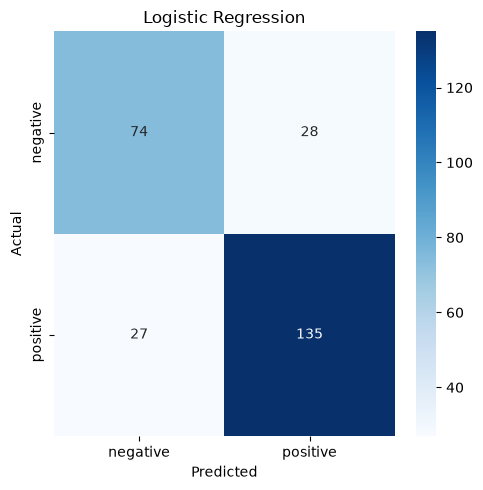

In [ ]:
#Logistic Regression Confusion Matrix
fig, axes = plt.subplots(figsize=(5, 5))

cm = confusion_matrix(y_test, pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'], ax=axes)
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')
axes.set_title('Logistic Regression')

plt.tight_layout()
plt.show()


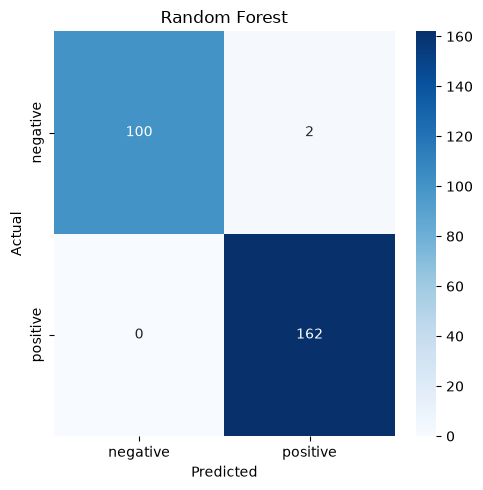

In [46]:
# Random Forest Confusion Matrix
fig, axes = plt.subplots(figsize=(5, 5))

cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'], ax=axes)
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')
axes.set_title('Random Forest')

plt.tight_layout()
plt.show()


- **False positive** (predicted heart attack, actually negative) → patient gets unnecessary follow-up
  tests or stress — costly and inconvenient, but not dangerous on its own.
- **False negative** (predicted no heart attack, actually positive) → a real heart attack case is
  missed — this is the far more serious error in a medical screening context.

Because false negatives matter more here, **recall** (how many true positive cases were actually
caught) deserves more weight than raw accuracy when judging which model is better.


## Fit and Evaluate Through the Pipeline

Note we pass the **unscaled `X_train`/`X_test`** here — no manual scaling or feature engineering
step beforehand. The pipeline itself handles every step internally, in the correct order, every time it's called.


Everything from raw features to a trained model — feature engineering, scaling, and the classifier —
combined into a single `Pipeline` object. 

We use **Logistic Regression** as the pipelined model here (not Random Forest) —  we noted on
Troponin/CK-MB near-perfectly separating the classes means Random Forest's ~99% score reflects
memorizing that separation more than genuine model skill. Logistic Regression's more modest, honest
score is the safer choice to standardize on going forward.



In [55]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000)),
])
pipe.fit(X_train, y_train)

y_pred_pipeline = pipe.predict(X_test)
y_proba_pipeline = pipe.predict_proba(X_test)[:, 1]

print("Random Forest — Test Set Performance")
print("Accuracy:", accuracy_score(y_test,y_pred_pipeline))
print("Precision:", precision_score(y_test,y_pred_pipeline))
print("Recall:",recall_score(y_test, y_pred_pipeline))
print("F1 Score:",f1_score(y_test,y_pred_pipeline))
print("ROC-AUC:", roc_auc_score(y_test,y_pred_pipeline))

Random Forest — Test Set Performance
Accuracy: 0.7916666666666666
Precision: 0.8282208588957055
Recall: 0.8333333333333334
F1 Score: 0.8307692307692308
ROC-AUC: 0.7794117647058825


In [56]:
cv_pipeline = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)

pipeline_cv_summary = pd.Series(
    {m: cv_pipeline['test_'+m].mean() for m in scoring}).round(3)

pipeline_cv_summary

accuracy     0.788
precision    0.825
recall       0.833
f1           0.829
roc_auc      0.875
dtype: float64